# sim3 visualization

This notebook reads the aggregated `sim3` output and makes a few simple plots to show how alignment behavior changes as mutation error increases.

## What this notebook plots

- error rate vs percent identity
- error rate vs bit score
- error rate vs gaps
- an optional scatter plot of bit score vs percent identity

It also saves the figures into a `plots/` directory next to the metrics table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import pandas as pd
from pathlib import Path

metrics_path = Path("../results/sim3/test/seed42/metrics_all.tsv")
print(metrics_path.resolve())
print(metrics_path.exists())

df = pd.read_csv(metrics_path, sep="\t")
df.head()

/home/ha-ibnu/Code/pairwise_sim/results/sim3/test/seed42/metrics_all.tsv
True


,seq_id,error_rate,seed,len_ref,len_query,n_sub,n_ins,n_del,bitscore,evalue,align_len,pct_ident,gaps,run_dir
0,test,0.0,42,2277,2277,0,0,0,4107.0,0.0,2277,100.0,0,results/sim3/test/seed42/e000
1,test,1.0,42,2277,2278,16,4,3,3985.0,0.0,2281,99.0,7,results/sim3/test/seed42/e001
2,test,2.0,42,2277,2277,32,7,7,3862.0,0.0,2284,98.0,14,results/sim3/test/seed42/e002
3,test,3.0,42,2277,2277,48,10,10,3752.0,0.0,2286,97.0,18,results/sim3/test/seed42/e003
4,test,4.0,42,2277,2276,64,13,14,3638.0,0.0,2287,96.0,25,results/sim3/test/seed42/e004


In [9]:
# Update this path if you run a different experiment.
metrics_path = Path('../results/sim3/test/seed42/metrics_all.tsv')

if not metrics_path.exists():
    raise FileNotFoundError(f'Metrics file not found: {metrics_path.resolve()}')

plots_dir = metrics_path.parent / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(metrics_path, sep='\t')
df = df.sort_values('error_rate').reset_index(drop=True)
df.head()

,seq_id,error_rate,seed,len_ref,len_query,n_sub,n_ins,n_del,bitscore,evalue,align_len,pct_ident,gaps,run_dir
0,test,0.0,42,2277,2277,0,0,0,4107.0,0.0,2277,100.0,0,results/sim3/test/seed42/e000
1,test,1.0,42,2277,2278,16,4,3,3985.0,0.0,2281,99.0,7,results/sim3/test/seed42/e001
2,test,2.0,42,2277,2277,32,7,7,3862.0,0.0,2284,98.0,14,results/sim3/test/seed42/e002
3,test,3.0,42,2277,2277,48,10,10,3752.0,0.0,2286,97.0,18,results/sim3/test/seed42/e003
4,test,4.0,42,2277,2276,64,13,14,3638.0,0.0,2287,96.0,25,results/sim3/test/seed42/e004


In [10]:
df[['error_rate', 'pct_ident', 'bitscore', 'gaps', 'len_ref', 'len_query']].describe()

,error_rate,pct_ident,bitscore,gaps,len_ref,len_query
count,31.000000,31.000000,31.000000,31.000000,31.0,31.000000
mean,15.000000,85.870968,2448.064516,80.258065,2277.0,2277.000000
std,9.092121,8.257287,964.499488,44.737730,0.0,0.516398
min,0.000000,73.000000,933.000000,0.000000,2277.0,2276.000000
25%,7.500000,78.500000,1625.500000,46.000000,2277.0,2277.000000
50%,15.000000,86.000000,2431.000000,81.000000,2277.0,2277.000000
75%,22.500000,92.500000,3239.000000,119.500000,2277.0,2277.000000
max,30.000000,100.000000,4107.000000,153.000000,2277.0,2278.000000


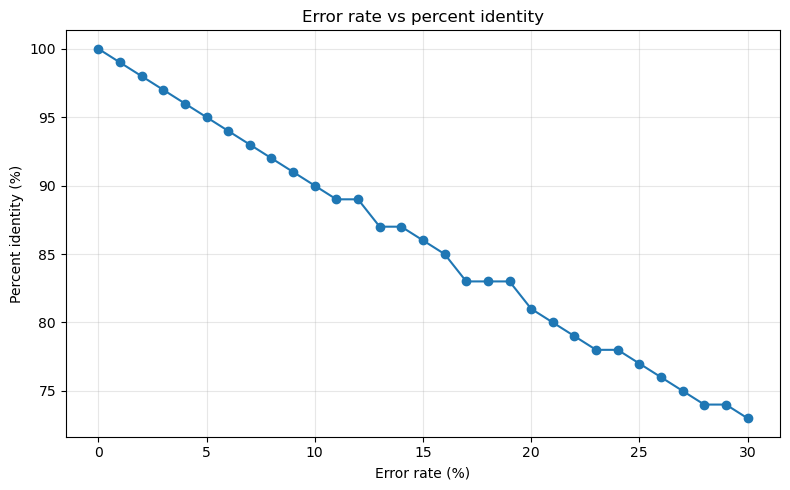

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(df['error_rate'], df['pct_ident'], marker='o')
plt.xlabel('Error rate (%)')
plt.ylabel('Percent identity (%)')
plt.title('Error rate vs percent identity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'error_vs_pct_identity.png', dpi=300, bbox_inches='tight')
plt.show()

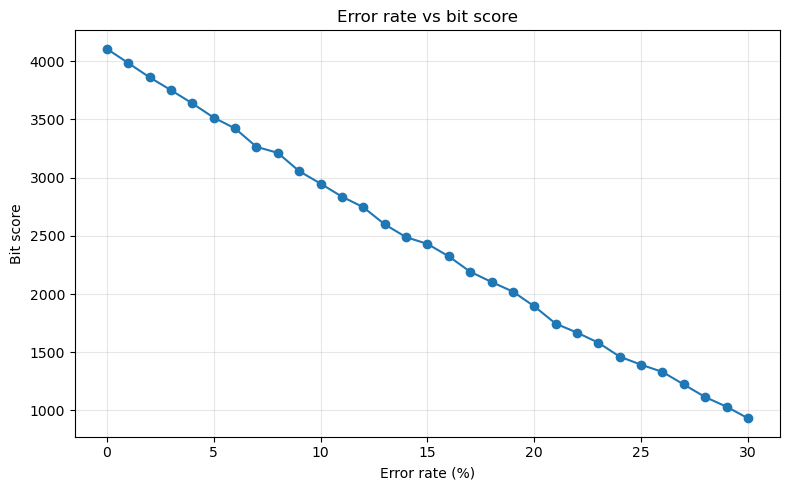

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(df['error_rate'], df['bitscore'], marker='o')
plt.xlabel('Error rate (%)')
plt.ylabel('Bit score')
plt.title('Error rate vs bit score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'error_vs_bitscore.png', dpi=300, bbox_inches='tight')
plt.show()

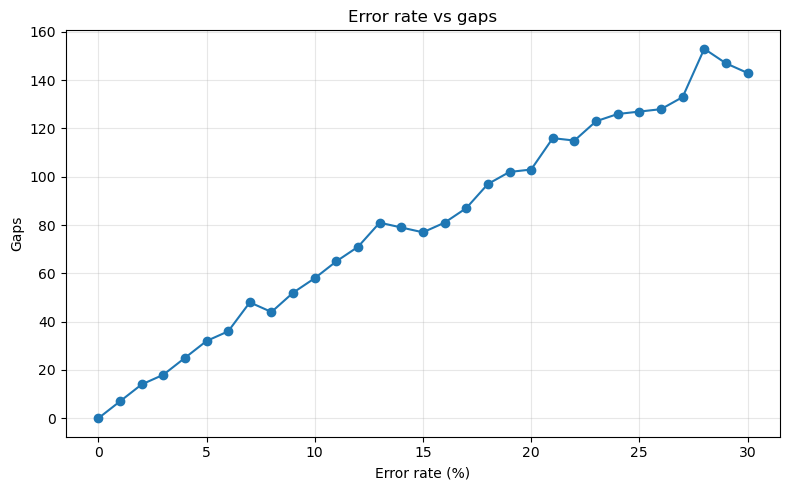

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(df['error_rate'], df['gaps'], marker='o')
plt.xlabel('Error rate (%)')
plt.ylabel('Gaps')
plt.title('Error rate vs gaps')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'error_vs_gaps.png', dpi=300, bbox_inches='tight')
plt.show()

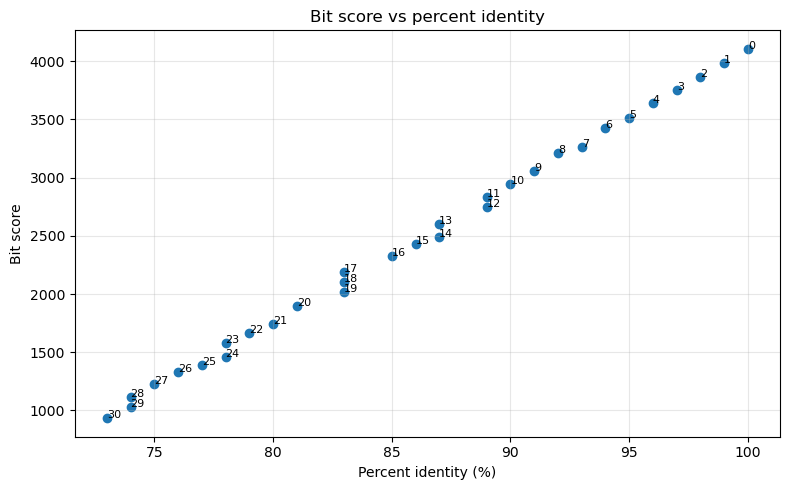

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['pct_ident'], df['bitscore'])
for _, row in df.iterrows():
    plt.annotate(int(round(row['error_rate'])), (row['pct_ident'], row['bitscore']), fontsize=8)
plt.xlabel('Percent identity (%)')
plt.ylabel('Bit score')
plt.title('Bit score vs percent identity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'bitscore_vs_pct_identity.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretation notes

Expected behavior:

- percent identity should generally decrease as error rate increases
- bit score should generally decrease
- gaps should generally increase, though not always perfectly monotonically because BLAST optimizes a local gapped alignment
- query length may fluctuate slightly because insertions and deletions can balance or differ by a few events after rounding


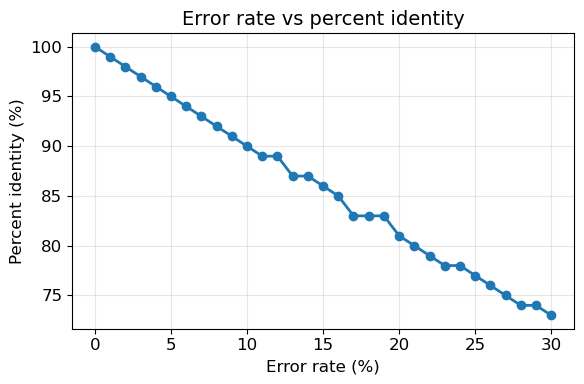

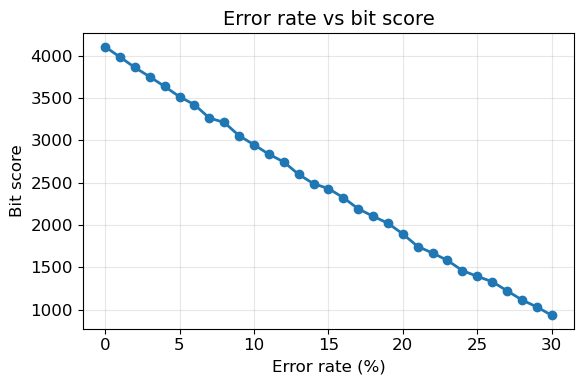

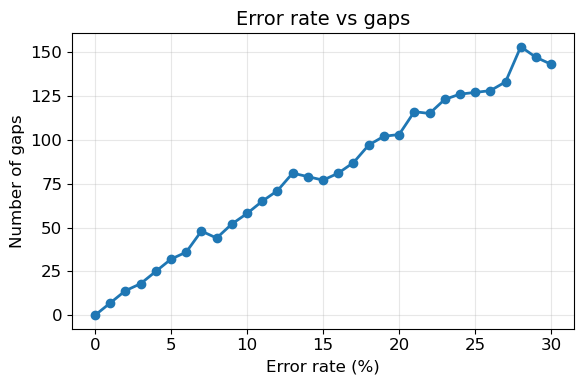

In [15]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

def save_plot(x, y, xlabel, ylabel, title, filename):
    plt.figure(figsize=(6, 4))
    plt.plot(x, y, marker="o", linewidth=2)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(plots_dir / filename, dpi=300)
    plt.show()

# Identity
save_plot(
    df["error_rate"], df["pct_ident"],
    "Error rate (%)", "Percent identity (%)",
    "Error rate vs percent identity",
    "error_vs_identity.png"
)

# Bit score
save_plot(
    df["error_rate"], df["bitscore"],
    "Error rate (%)", "Bit score",
    "Error rate vs bit score",
    "error_vs_bitscore.png"
)

# Gaps
save_plot(
    df["error_rate"], df["gaps"],
    "Error rate (%)", "Number of gaps",
    "Error rate vs gaps",
    "error_vs_gaps.png"
)

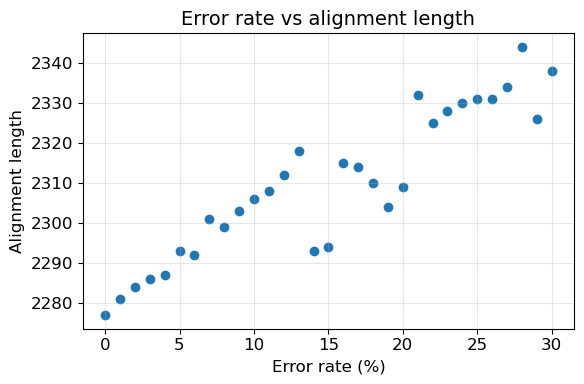

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(df["error_rate"], df["align_len"])
plt.xlabel("Error rate (%)")
plt.ylabel("Alignment length")
plt.title("Error rate vs alignment length")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / "error_vs_alignment_length.png", dpi=300)
plt.show()

In [19]:
import re

def parse_alignment_positions(aln_file):
    x = []
    y = []

    q_seq = None
    q_start = None

    with open(aln_file) as f:
        for line in f:
            line = line.rstrip()

            # only match real alignment block lines like:
            # Query  1     ACTG...  60
            m_q = re.match(r"^Query\s+(\d+)\s+([A-Z\-]+)\s+\d+$", line)
            if m_q:
                q_start = int(m_q.group(1))
                q_seq = m_q.group(2)
                continue

            # only match real subject alignment block lines like:
            # Sbjct  1     ACTG...  60
            m_s = re.match(r"^Sbjct\s+(\d+)\s+([A-Z\-]+)\s+\d+$", line)
            if m_s and q_seq is not None and q_start is not None:
                s_start = int(m_s.group(1))
                s_seq = m_s.group(2)

                q_pos = q_start
                s_pos = s_start

                for q_base, s_base in zip(q_seq, s_seq):
                    if q_base != "-" and s_base != "-":
                        x.append(q_pos)
                        y.append(s_pos)

                    if q_base != "-":
                        q_pos += 1
                    if s_base != "-":
                        s_pos += 1

                q_seq = None
                q_start = None

    return x, y

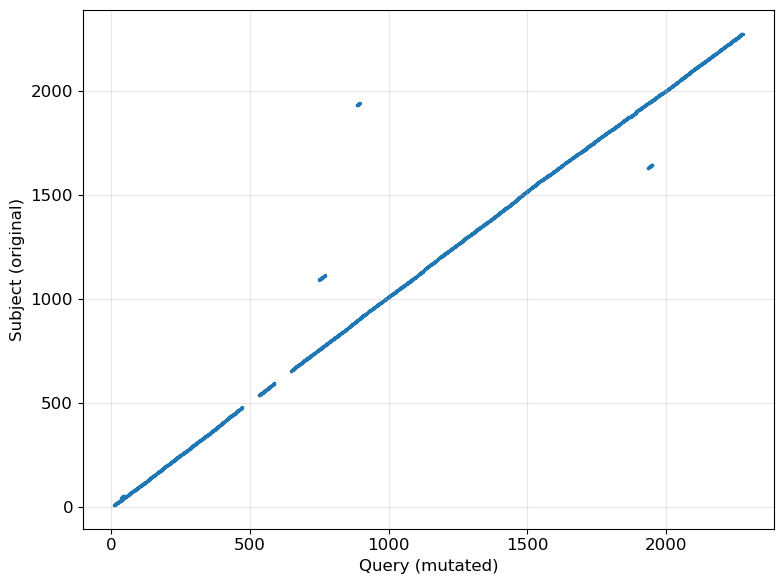

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=2)

plt.xlabel("Query (mutated)")
plt.ylabel("Subject (original)")
# plt.title("Dot plot: query vs subject")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(plots_dir / "dotplot_sim2_e020.png", dpi=300)  # ← save here
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../results/sim2/test/e000_s42/aln.txt'

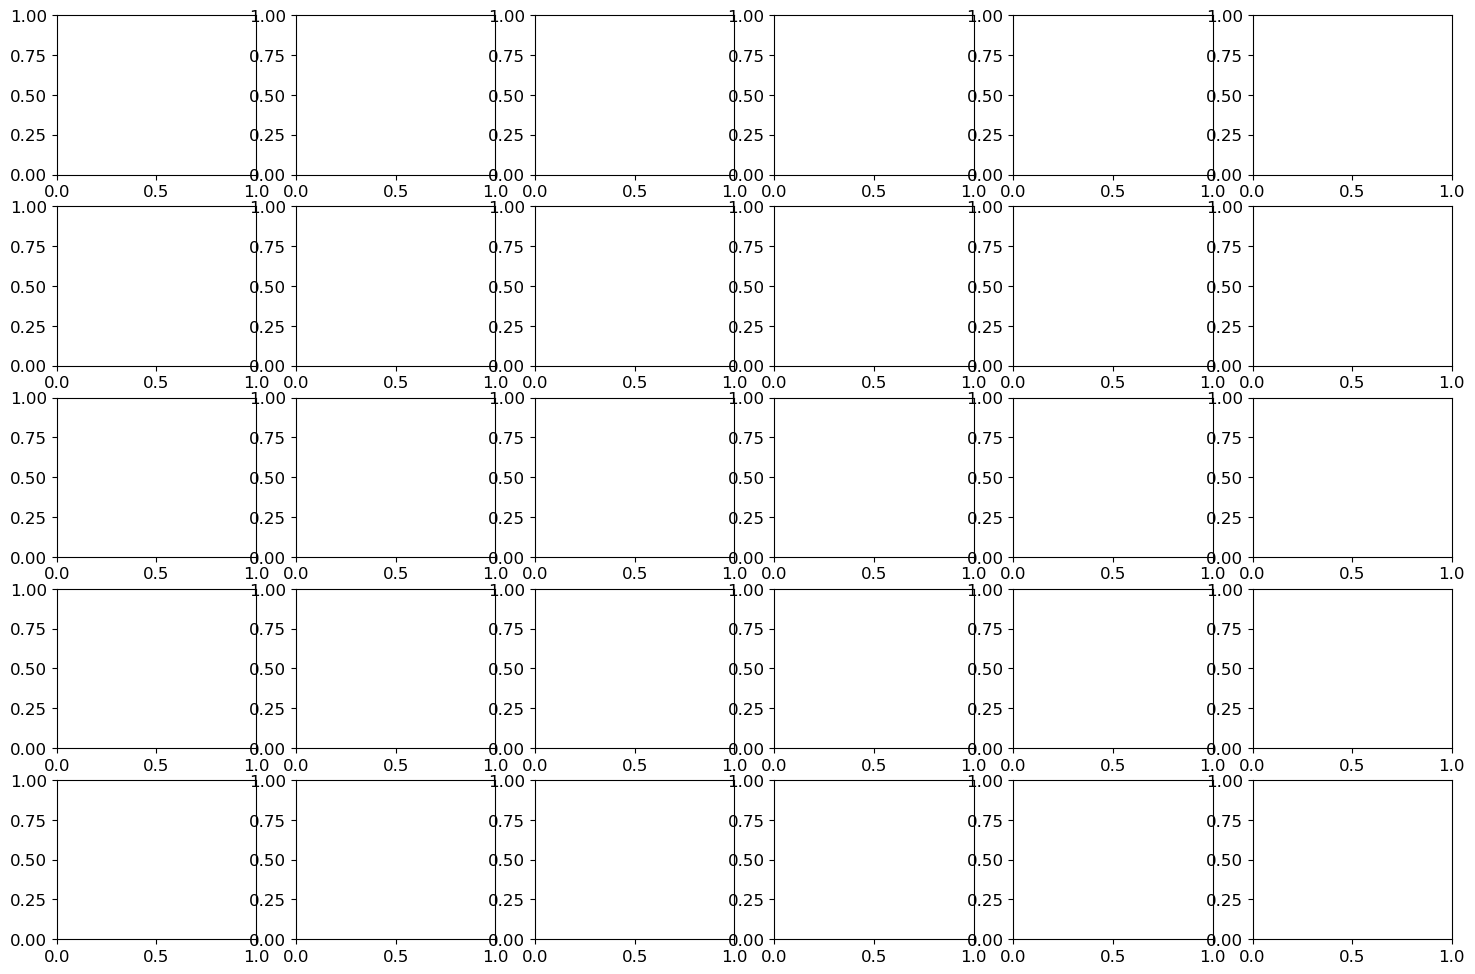

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 6, figsize=(18, 12))  # 30 plots (0–30%)
axes = axes.flatten()

for e in range(31):
    aln_file = f"../results/sim2/test/e{e:03d}_s42/aln.txt"
    
    x, y = parse_alignment_positions(aln_file)
    
    ax = axes[e]
    ax.scatter(x, y, s=1)
    ax.set_title(f"{e}%")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Dot plots across error rates")
plt.tight_layout()
plt.show()

In [24]:
import os

base = "../results/sim2/test"

for d in sorted(os.listdir(base)):
    print(d)

e020_s42


In [26]:
base = "../results/sim3/test/seed42"

import os
for d in sorted(os.listdir(base)):
    print(d)

e000
e001
e002
e003
e004
e005
e006
e007
e008
e009
e010
e011
e012
e013
e014
e015
e016
e017
e018
e019
e020
e021
e022
e023
e024
e025
e026
e027
e028
e029
e030
metrics_all.tsv
plots


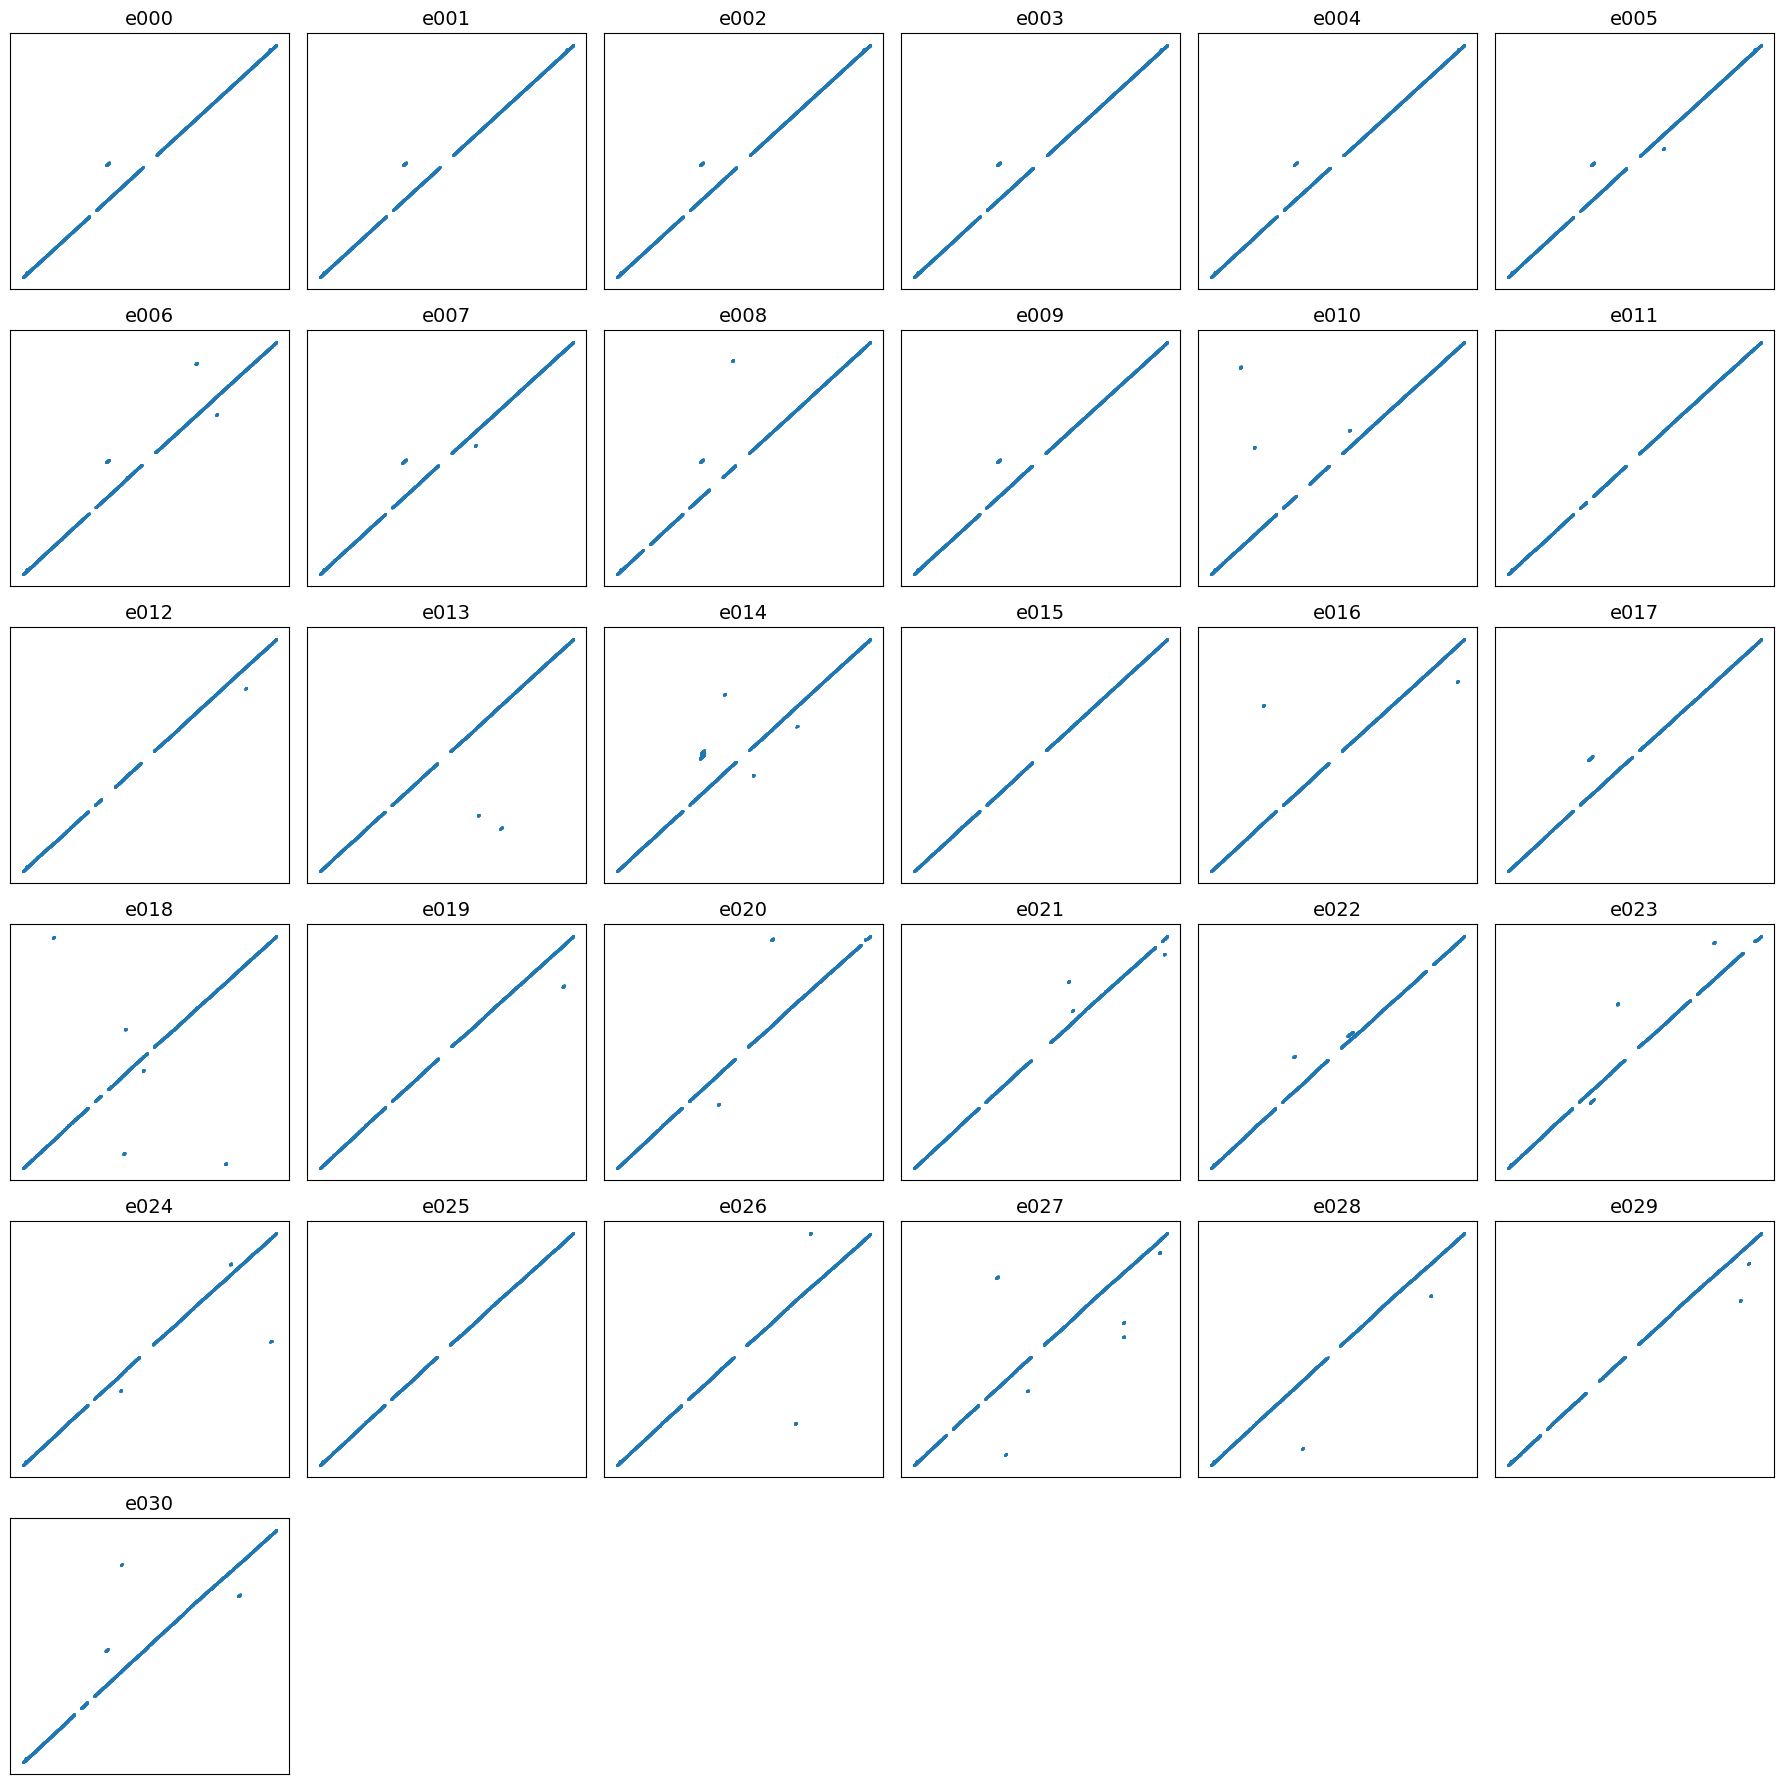

In [31]:
import os
import matplotlib.pyplot as plt

base = "../results/sim3/test/seed42"
dirs = sorted([d for d in os.listdir(base) if d.startswith("e")])

fig, axes = plt.subplots(6, 6, figsize=(18, 18))
axes = axes.flatten()

for i, d in enumerate(dirs):
    aln_file = f"{base}/{d}/aln.txt"

    if not os.path.exists(aln_file):
        continue

    x, y = parse_alignment_positions(aln_file)

    ax = axes[i]
    ax.scatter(x, y, s=1)
    ax.set_title(d)
    ax.set_xticks([])
    ax.set_yticks([])

# hide empty panels
for j in range(len(dirs), len(axes)):
    axes[j].axis("off")

# plt.suptitle("Dot plots across error rates (sim3)")
plt.tight_layout()
plt.savefig(plots_dir / "dotplot_all_errors.png", dpi=300, bbox_inches="tight")
plt.show()

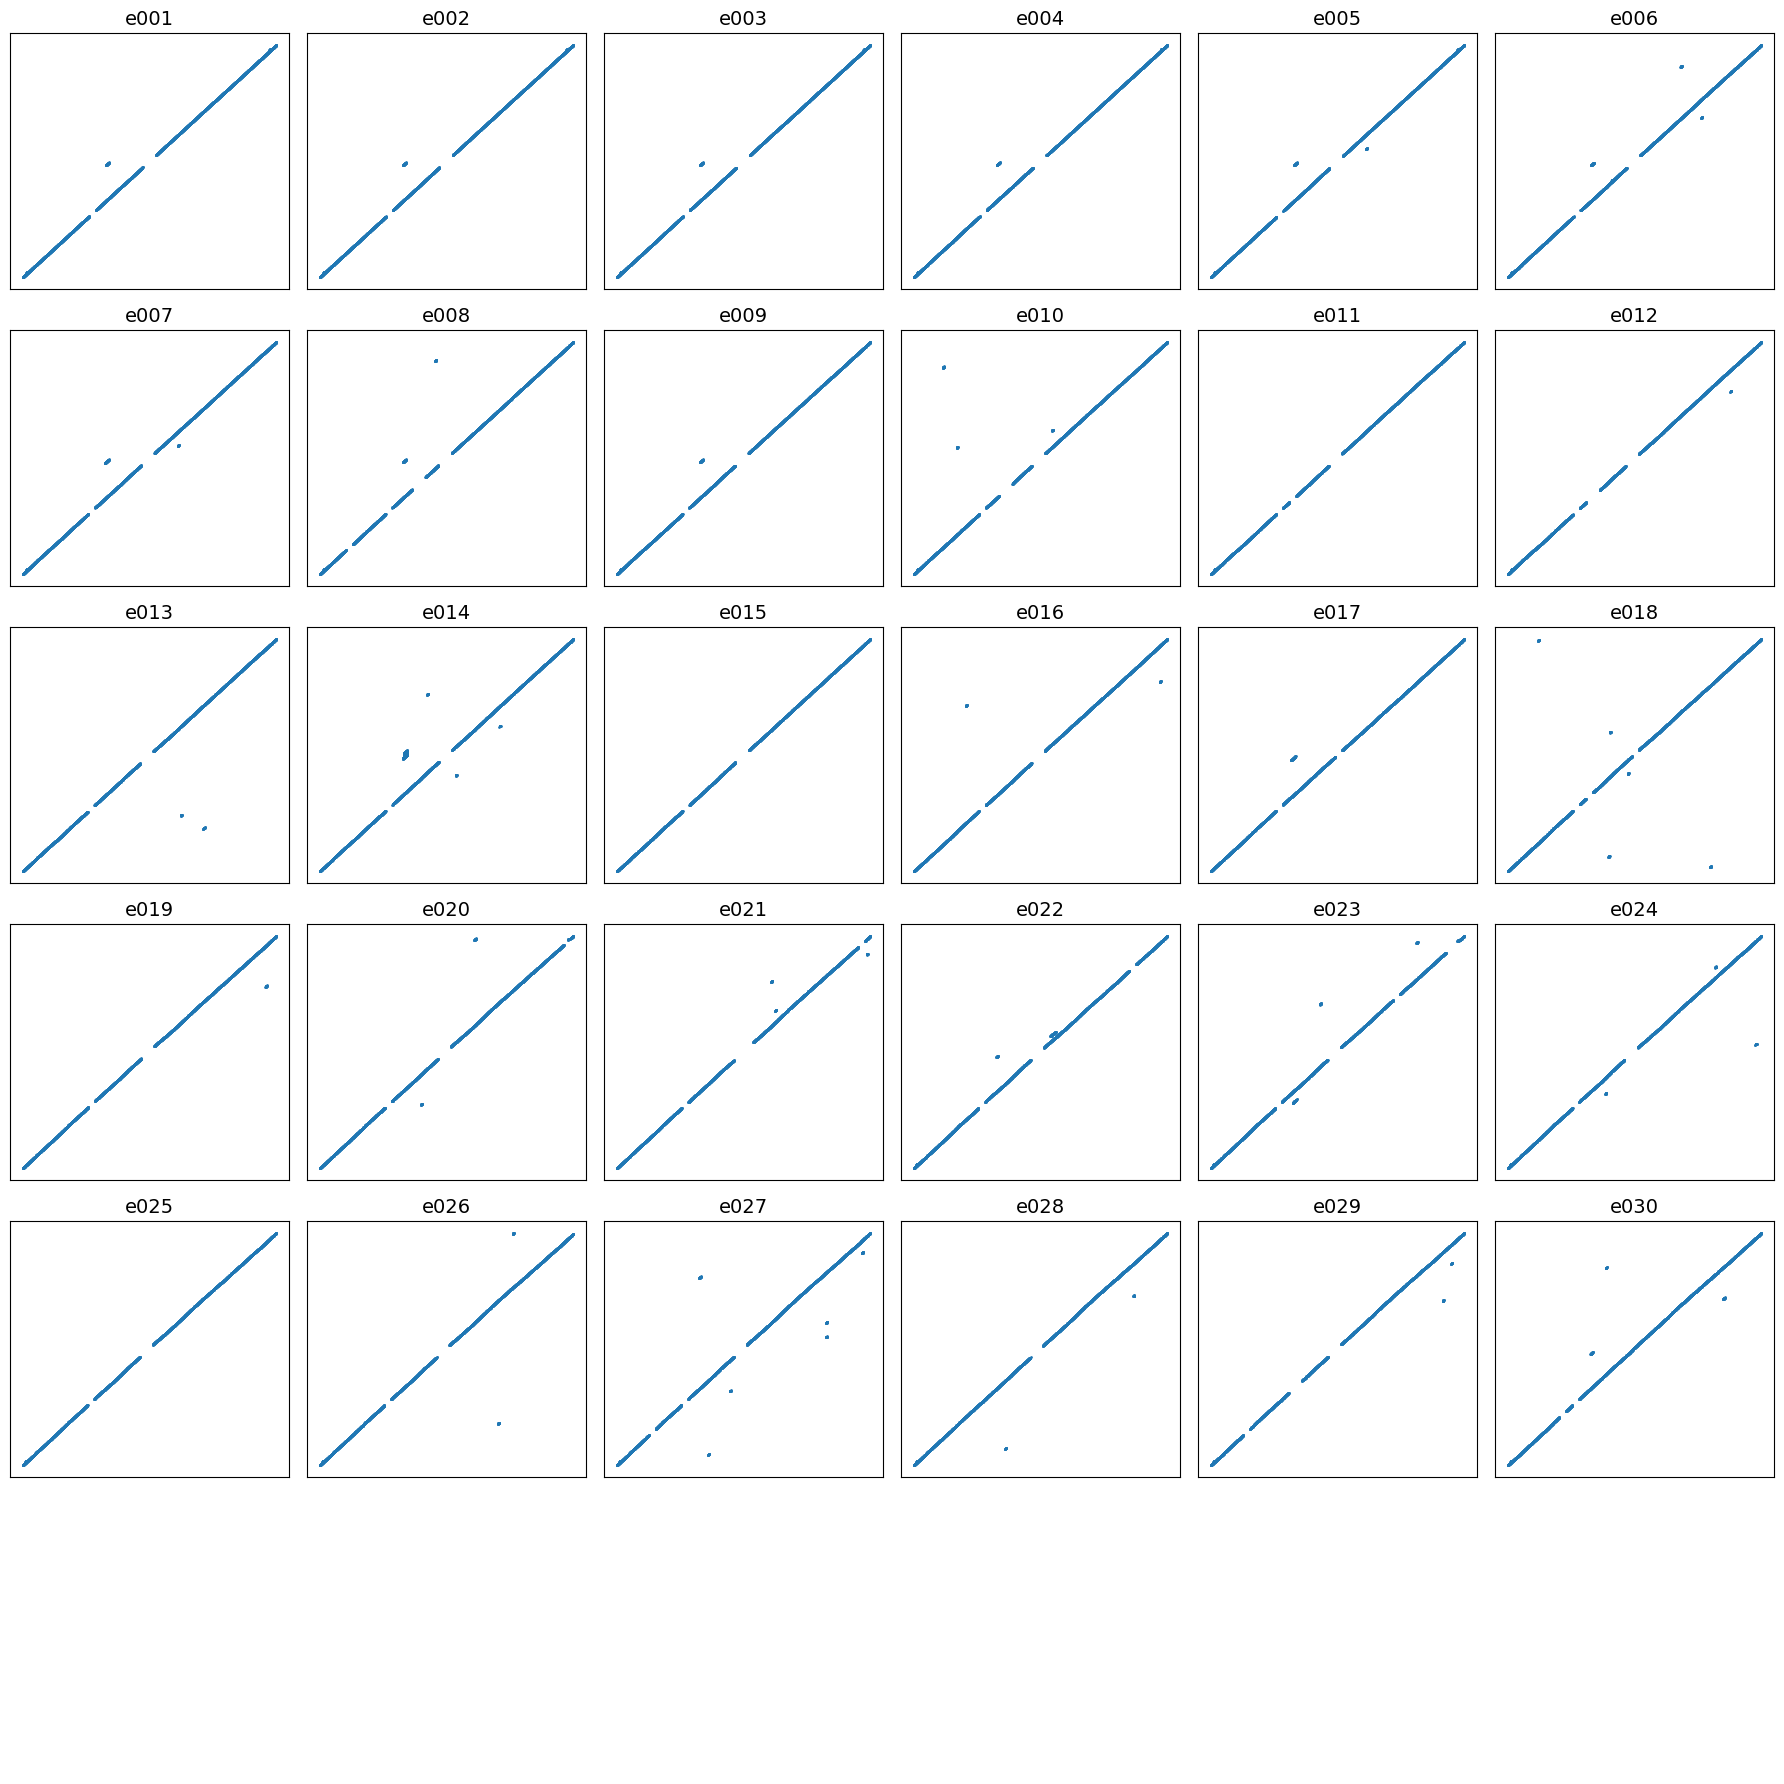

In [36]:
import os
import matplotlib.pyplot as plt

base = "../results/sim3/test/seed42"
dirs = sorted([d for d in os.listdir(base) if d.startswith("e")])

fig, axes = plt.subplots(6, 6, figsize=(18, 18))
axes = axes.flatten()

i = 0  # 👈 manual index

for d in dirs:
    e = int(d[1:4])  # extract error number from "e000", "e001", ...

    if e == 0:   # ⛔ skip error 0
        continue

    aln_file = f"{base}/{d}/aln.txt"

    if not os.path.exists(aln_file):
        continue

    x, y = parse_alignment_positions(aln_file)

    ax = axes[i]
    ax.scatter(x, y, s=1)
    ax.set_title(d)
    ax.set_xticks([])
    ax.set_yticks([])

    i += 1  # 👈 only increment when used

# hide unused panels
for j in range(i, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(plots_dir / "dotplot_no_e000.png", dpi=300, bbox_inches="tight")
plt.show()

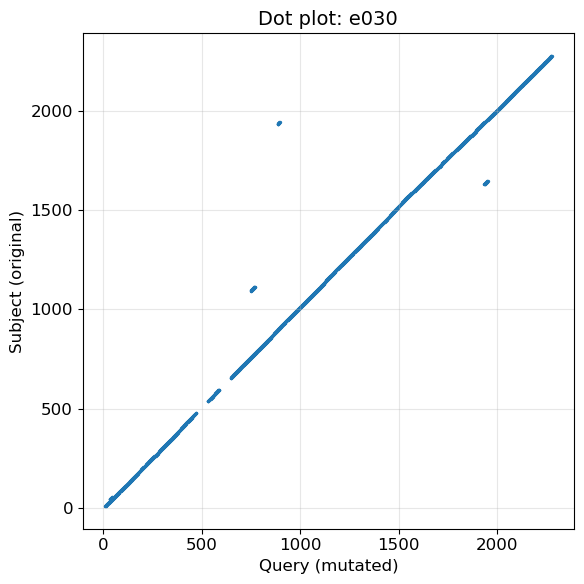

In [38]:
import matplotlib.pyplot as plt

base = "../results/sim3/test/seed42"

# choose error level here
d = "e030"   # change to e001, e010, e030, etc.

aln_file = f"{base}/{d}/aln.txt"

x, y = parse_alignment_positions(aln_file)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=2)

plt.xlabel("Query (mutated)")
plt.ylabel("Subject (original)")
plt.title(f"Dot plot: {d}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / f"dotplot_{d}.png", dpi=300, bbox_inches="tight")
plt.show()